In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import discretize
from discretize import TensorMesh

from discretize.utils import mkvc, active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

write_output = False

import torch

In [2]:
# 1) Modelo (Δσ)
# El NPY trae contraste de conductividad Δσ en S/m 

# Frecuencias en las que se va a hacer el modelado
frequency_list = np.logspace(-4, 2, 7)

# Carga de la malla usada para el modelo 3D de conductividad 
mesh = discretize.utils.load_mesh("../../../../models/Toy5/mesh_Toy5_MT.json")

# Carga del modelo 3D de conductividad
sigma = np.load("../../../../models/Toy5/model_Toy5_MT.npy", allow_pickle=True)

# Modelo de conductividad 
sigBG = np.ones(mesh.nC) * 2e-3
air_cells = np.isclose(sigma, 1e-8)
sigBG[air_cells] = 1e-8

# Ubicación del receptor para el modelado
rx_loc = np.array([
    [0.0, 0.0, -53.7],
])

print("mesh =", mesh)
print("mesh.nC=", mesh.nC)
print("mesh.nEx=", mesh.nEx)
print("mesh.nEy=", mesh.nEy)
print("mesh.nEz=", mesh.nEz)
print("frequency_list =", frequency_list)
print("rx_loc =", rx_loc)

mesh = 
  TensorMesh: 4,312 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     14     -3,439.01      3,439.01    250.00    928.23    1.30
   y     14     -3,439.01      3,439.01    250.00    928.23    1.30
   z     22     -3,087.43      3,387.43    150.00    724.02    1.30


mesh.nC= 4312
mesh.nEx= 4830
mesh.nEy= 4830
mesh.nEz= 4950
frequency_list = [1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
rx_loc = [[  0.    0.  -53.7]]


In [3]:
mesh

TensorMesh: 4,312 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     14     -3,439.01      3,439.01    250.00    928.23    1.30
   y     14     -3,439.01      3,439.01    250.00    928.23    1.30
   z     22     -3,087.43      3,387.43    150.00    724.02    1.30

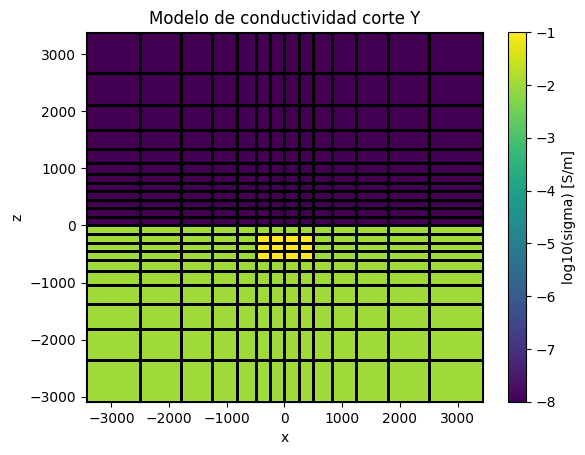

In [4]:
# 2) Plot del modelo de conductividad 3D
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="Y")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte Y")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

In [5]:
# 3) Lista de receptores: impedancia compleja y tipper complejo
from simpeg.electromagnetics import natural_source as NSEM
receiver_list = []

for rx_orientation in ["xx", "xy", "yx", "yy"]:
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="imag")
    )

for rx_orientation in ["zx", "zy"]:
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="imag")
    )

source_list = [
    NSEM.Src.PlanewaveXYPrimary(receiver_list, freq)
    for freq in frequency_list
]

survey = NSEM.Survey(source_list)

print("Número de fuentes:", len(source_list))
print("Número de receptores por fuente:", len(receiver_list))

Número de fuentes: 7
Número de receptores por fuente: 12


In [6]:
# 4) Forward

problem = NSEM.Simulation3DPrimarySecondary(
    mesh=mesh,
    survey=survey,
    sigma=sigma,
    sigmaPrimary=sigBG,
    forward_only=True,
)

dobs = problem.dpred()
data = NSEM.Data(survey=survey, dobs=dobs)
#data.relative_error = 0.1
#data.noise_floor = 0.0

print("Estaciones físicas:", rx_loc.shape[0])
print("Tipos de medición definidos:", len(receiver_list))
print("Frecuencias:", len(source_list))
print("Datos totales esperados:", rx_loc.shape[0] * len(receiver_list) * len(source_list))

c:\Users\carlo\anaconda3\envs\P8091\lib\site-packages\simpeg\base\pde_simulation.py:490: DefaultSolverWarning: Using the default solver: SolverLU. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)
c:\Users\carlo\anaconda3\envs\P8091\lib\site-packages\pymatsolver\wrappers.py:81: SparseEfficiencyWarning: splu converted its input to CSC format
  self.solver = fun(self.A, **self.kwargs)


Estaciones físicas: 1
Tipos de medición definidos: 12
Frecuencias: 7
Datos totales esperados: 84


In [7]:
# 5) Exportación de la respuesta calculada
n_rec = rx_loc.shape[0]
n_freq = len(frequency_list)

impedance_simpeg = np.zeros((n_rec, n_freq, 2, 2), dtype=complex)
tipper_simpeg = np.zeros((n_rec, n_freq, 2), dtype=complex)

for ifreq, src in enumerate(survey.source_list):
    # leer por receptor en el mismo survey
    zxx_r = np.asarray(data[src, receiver_list[0]])
    zxx_i = np.asarray(data[src, receiver_list[1]])

    zxy_r = np.asarray(data[src, receiver_list[2]])
    zxy_i = np.asarray(data[src, receiver_list[3]])

    zyx_r = np.asarray(data[src, receiver_list[4]])
    zyx_i = np.asarray(data[src, receiver_list[5]])

    zyy_r = np.asarray(data[src, receiver_list[6]])
    zyy_i = np.asarray(data[src, receiver_list[7]])

    tzx_r = np.asarray(data[src, receiver_list[8]])
    tzx_i = np.asarray(data[src, receiver_list[9]])

    tzy_r = np.asarray(data[src, receiver_list[10]])
    tzy_i = np.asarray(data[src, receiver_list[11]])

    impedance_simpeg[:, ifreq, 0, 0] = zxx_r + 1j * zxx_i
    impedance_simpeg[:, ifreq, 0, 1] = zxy_r + 1j * zxy_i
    impedance_simpeg[:, ifreq, 1, 0] = zyx_r + 1j * zyx_i
    impedance_simpeg[:, ifreq, 1, 1] = zyy_r + 1j * zyy_i

    tipper_simpeg[:, ifreq, 0] = tzx_r + 1j*tzx_i
    tipper_simpeg[:, ifreq, 1] = tzy_r + 1j*tzy_i

# Guardar en archivos .npy la impedancia y el tipper
np.save("impedance_SimPEG_Toy5.npy", impedance_simpeg)
np.save("tipper_SimPEG_Toy5.npy", tipper_simpeg)

In [8]:
plot_location = rx_loc[0, :2]
print("plot_location=",plot_location)

plot_location= [0. 0.]


C:\Users\carlo\AppData\Local\Temp\ipykernel_16460\2196681530.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.invert_xaxis()
C:\Users\carlo\AppData\Local\Temp\ipykernel_16460\2196681530.py:11: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.invert_xaxis()


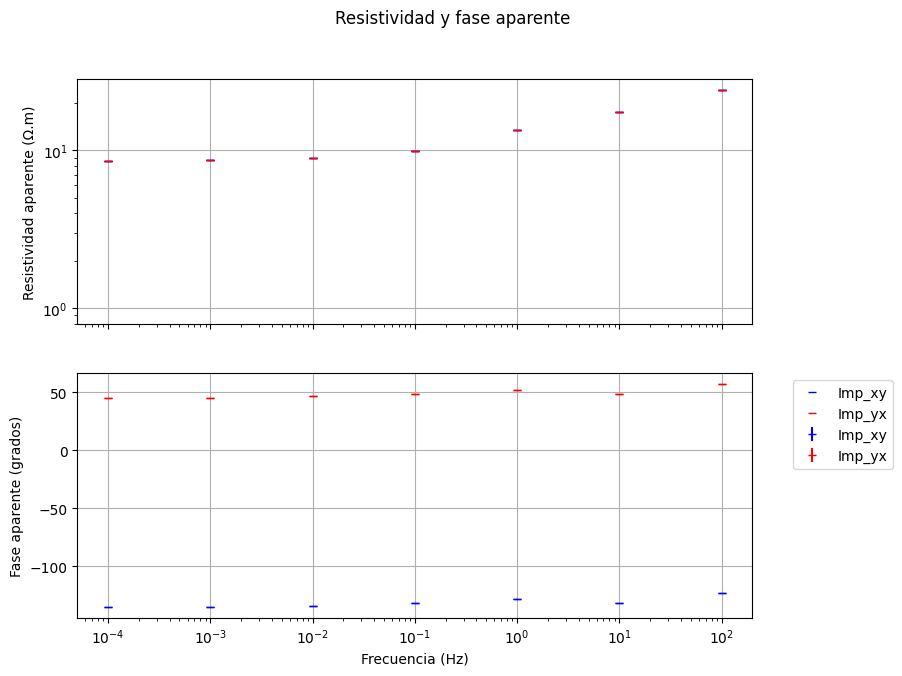

In [9]:
# 5) Plot 

# Plot de resistividad aparente y fase calculada con SimPEG
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plt.subplots_adjust(right=0.8)

irec = 0

ax_r, ax_p = axes
for ax in axes:
    ax.invert_xaxis()
    ax.set_xscale("log")
    ax.grid(True)

ax_r.set_yscale("log")
ax_r.set_ylabel("Resistividad aparente (Ω.m)")
ax_p.set_ylabel("Fase aparente (grados)")
ax_p.set_xlabel("Frecuencia (Hz)")

ax_r = data.plot_app_res(
    plot_location,
    components=["xy", "yx"],
    ax=ax_r,
    errorbars=True,
)

ax_p = data.plot_app_phs(
    plot_location,
    components=["xy", "yx"],
    ax=ax_p,
    errorbars=True,
)

ax_p.legend(bbox_to_anchor=(1.05, 1), loc=2)
fig.suptitle(f"Resistividad y fase aparente")
plt.show()

C:\Users\carlo\AppData\Local\Temp\ipykernel_16460\923321069.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.invert_xaxis()
C:\Users\carlo\AppData\Local\Temp\ipykernel_16460\923321069.py:8: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.invert_xaxis()


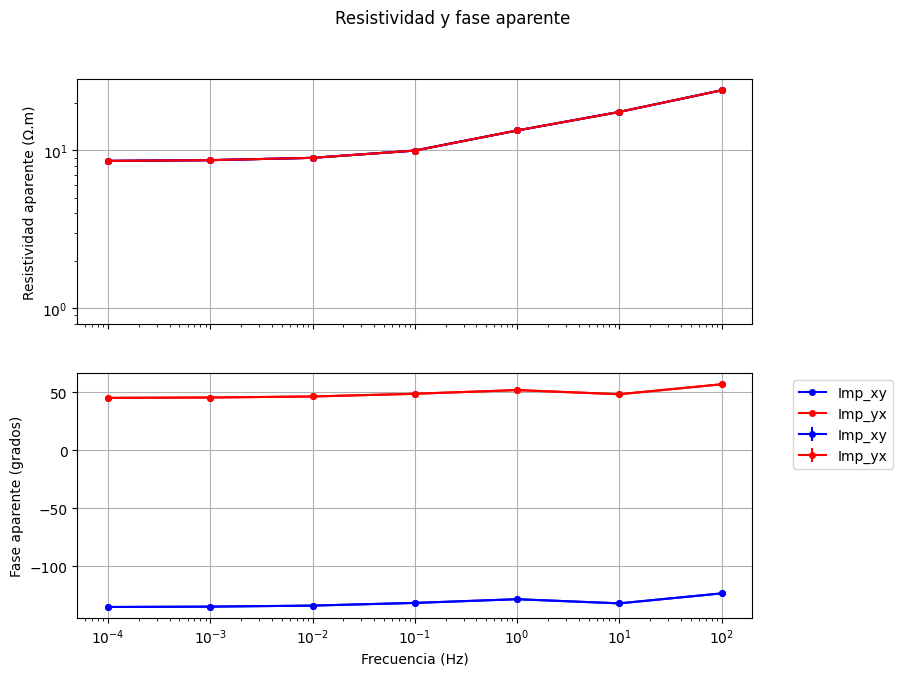

In [10]:
# Plot de resistividad aparente y fase calculada con SimPEG
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plt.subplots_adjust(right=0.8)

ax_r, ax_p = axes

for ax in axes:
    ax.invert_xaxis()
    ax.set_xscale("log")
    ax.grid(True)

ax_r.set_yscale("log")
ax_r.set_ylabel("Resistividad aparente (Ω.m)")
ax_p.set_ylabel("Fase aparente (grados)")
ax_p.set_xlabel("Frecuencia (Hz)")

# Resistividad aparente
ax_r = data.plot_app_res(
    plot_location,
    components=["xy", "yx"],
    ax=ax_r,
    errorbars=True,
)

# Fase aparente
ax_p = data.plot_app_phs(
    plot_location,
    components=["xy", "yx"],
    ax=ax_p,
    errorbars=True,
)

# Cambiar puntos por curvas continuas
for linea in ax_r.lines:
    linea.set_linestyle("-")
    linea.set_linewidth(1.5)
    linea.set_marker("o")
    linea.set_markersize(4)

for linea in ax_p.lines:
    linea.set_linestyle("-")
    linea.set_linewidth(1.5)
    linea.set_marker("o")
    linea.set_markersize(4)

ax_p.legend(bbox_to_anchor=(1.05, 1), loc=2)

fig.suptitle("Resistividad y fase aparente")
plt.show()

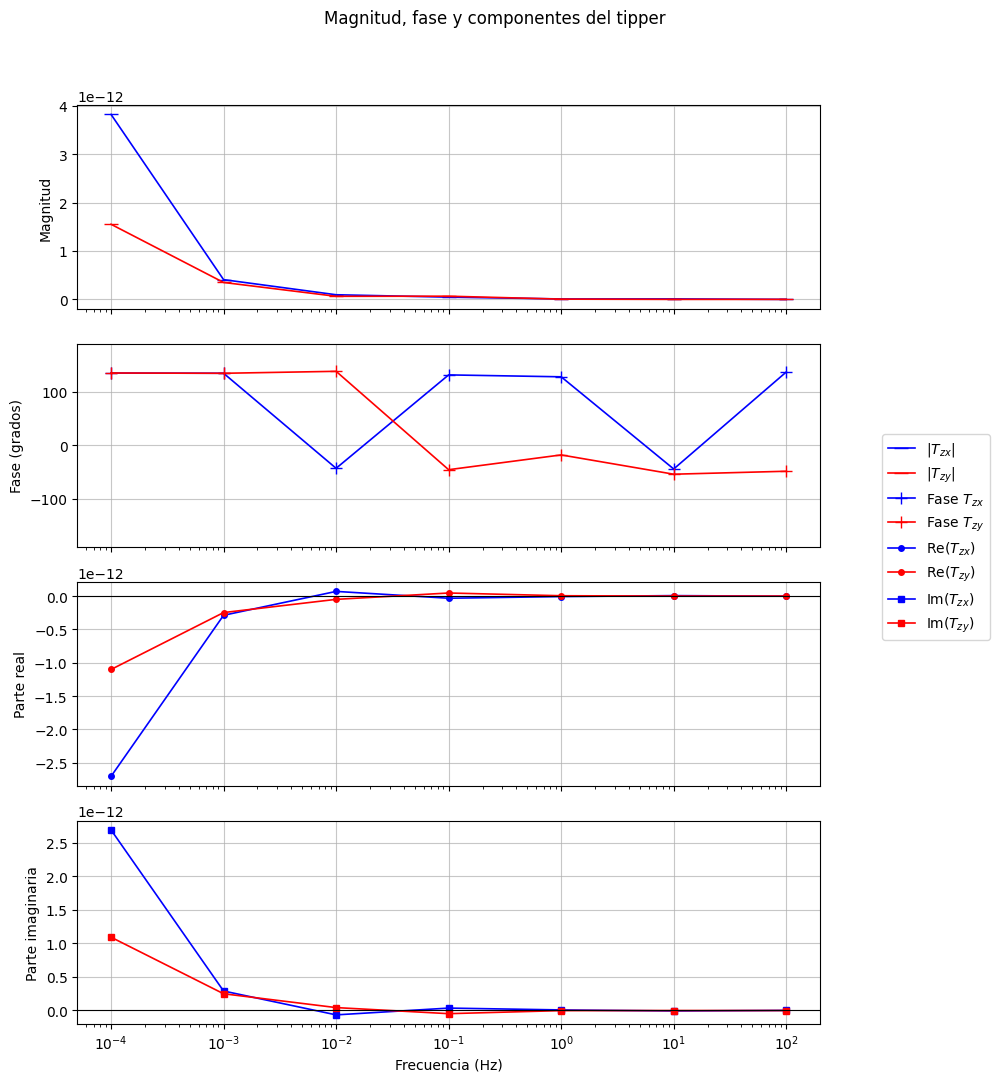

In [11]:
# Magnitud, fase, parte real e imaginaria del tipper calculada con SimPEG

Tzx_list = []
Tzy_list = []
frec = []

for src in survey.source_list:

    # Frecuencia asociada a cada fuente
    frec.append(src.frequency)

    # Componentes real e imaginaria
    tzx_r = np.atleast_1d(np.asarray(data[src, receiver_list[8]]))
    tzx_i = np.atleast_1d(np.asarray(data[src, receiver_list[9]]))

    tzy_r = np.atleast_1d(np.asarray(data[src, receiver_list[10]]))
    tzy_i = np.atleast_1d(np.asarray(data[src, receiver_list[11]]))

    # Construcción compleja del tipper
    Tzx_list.append(tzx_r + 1j * tzx_i)
    Tzy_list.append(tzy_r + 1j * tzy_i)

# (n_frecuencias, n_receptores)
Tzx = np.asarray(Tzx_list)
Tzy = np.asarray(Tzy_list)
frec = np.asarray(frec)

orden = np.argsort(frec)

frec = frec[orden]
Tzx = Tzx[orden, :]
Tzy = Tzy[orden, :]

# Magnitud, fase, real e imaginaria

Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = np.degrees(np.angle(Tzx))
Tpzy = np.degrees(np.angle(Tzy))

Tzx_real = np.real(Tzx)
Tzx_imag = np.imag(Tzx)

Tzy_real = np.real(Tzy)
Tzy_imag = np.imag(Tzy)

# Receptor a graficar
irec = 0

c_tzx = "blue"
c_tzy = "red"

fig, (ax_mag, ax_phi, ax_real, ax_imag) = plt.subplots(
    4,
    1,
    figsize=(10, 11),
    sharex=True
)

# Magnitud
ax_mag.plot(
    frec,
    Tmzx[:, irec],
    marker="_",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=10,
    label=r"$|T_{zx}|$"
)

ax_mag.plot(
    frec,
    Tmzy[:, irec],
    marker="_",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=10,
    label=r"$|T_{zy}|$"
)

ax_mag.set_xscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="major", alpha=0.7)

# Fase
ax_phi.plot(
    frec,
    Tpzx[:, irec],
    marker="+",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=8,
    label=r"Fase $T_{zx}$"
)

ax_phi.plot(
    frec,
    Tpzy[:, irec],
    marker="+",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=8,
    label=r"Fase $T_{zy}$"
)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_ylim(-190, 190)
ax_phi.grid(True, which="major", alpha=0.7)

# Parte real
ax_real.plot(
    frec,
    Tzx_real[:, irec],
    marker="o",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=4,
    label=r"Re($T_{zx}$)"
)

ax_real.plot(
    frec,
    Tzy_real[:, irec],
    marker="o",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=4,
    label=r"Re($T_{zy}$)"
)

ax_real.set_xscale("log")
ax_real.set_ylabel("Parte real")
ax_real.axhline(0, color="black", linewidth=0.8)
ax_real.grid(True, which="major", alpha=0.7)

# Parte imaginaria
ax_imag.plot(
    frec,
    Tzx_imag[:, irec],
    marker="s",
    linestyle="-",
    linewidth=1.2,
    color=c_tzx,
    markersize=4,
    label=r"Im($T_{zx}$)"
)

ax_imag.plot(
    frec,
    Tzy_imag[:, irec],
    marker="s",
    linestyle="-",
    linewidth=1.2,
    color=c_tzy,
    markersize=4,
    label=r"Im($T_{zy}$)"
)

ax_imag.set_xscale("log")
ax_imag.set_xlabel("Frecuencia (Hz)")
ax_imag.set_ylabel("Parte imaginaria")
ax_imag.axhline(0, color="black", linewidth=0.8)
ax_imag.grid(True, which="major", alpha=0.7)

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    ax.invert_xaxis()


handles, labels = [], []

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle("Magnitud, fase y componentes del tipper")

plt.tight_layout(rect=[0, 0, 0.84, 0.95])

plt.savefig(
    "Tipper_ModelingToy5_SimPEG.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# 6) Carga de respuestas para comparación
impedance_op = np.load("impedance_3D.npy")
impedance_sp = np.load("impedance_SimPEG_Toy5.npy")
tipper_op = np.load("tipper_3D.npy")
tipper_sp = np.load("tipper_SimPEG_Toy5.npy")

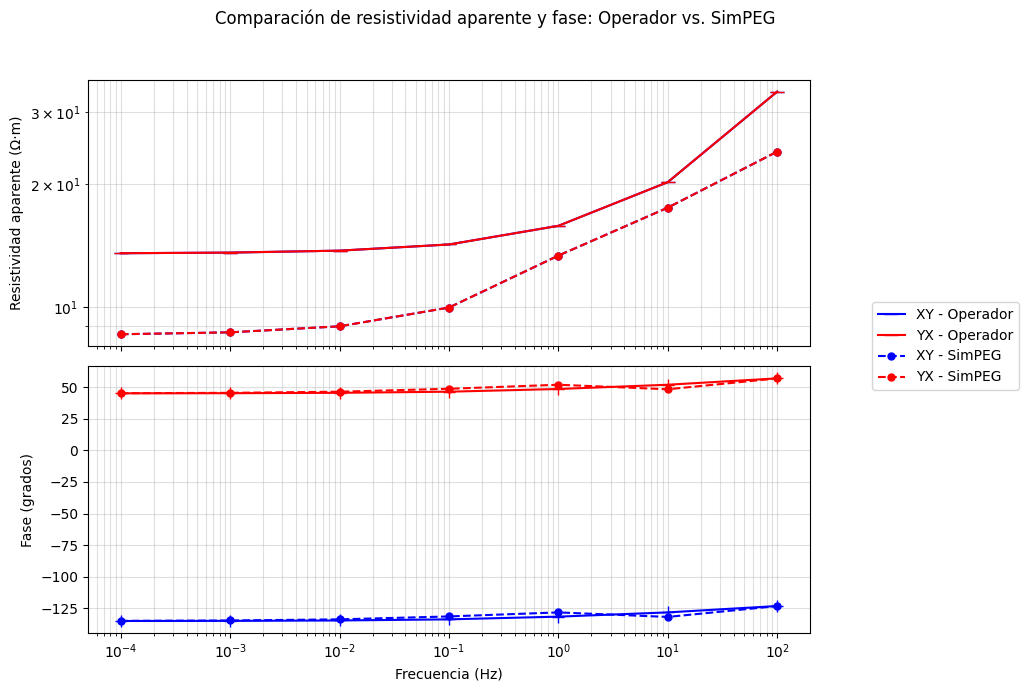

In [15]:
# 7) Plots de diferencia entre SimPEG y el operador

# Resistividad y fase aparente
mu_0 = 4 * np.pi * 1e-7

def apparent_resistivity(Z, frequency):
    omega = 2 * np.pi * np.asarray(frequency)
    return np.abs(Z)**2 / (mu_0 * omega)

def phase_deg(Z):
    return np.degrees(np.angle(Z))

# Extraer un receptor y las componentes XY / YX
irec = 0

# Ordenar frecuencias de menor a mayor para conectar las curvas
orden = np.argsort(frequency_list)
frec = frequency_list[orden]

# Operador 
Zxy_op = impedance_op[irec, orden, 0, 1]
Zyx_op = impedance_op[irec, orden, 1, 0]

# SimPEG
Zxy_sp = impedance_sp[irec, orden, 0, 1]
Zyx_sp = impedance_sp[irec, orden, 1, 0]

# Resistividad aparente
rho_xy_op = apparent_resistivity(Zxy_op, frec)
rho_yx_op = apparent_resistivity(Zyx_op, frec)

rho_xy_sp = apparent_resistivity(Zxy_sp, frec)
rho_yx_sp = apparent_resistivity(Zyx_sp, frec)

# Fase
phi_xy_op = phase_deg(Zxy_op)
phi_yx_op = phase_deg(Zyx_op)

phi_xy_sp = phase_deg(Zxy_sp)
phi_yx_sp = phase_deg(Zyx_sp)

# Plot comparativo
fig, (ax_rho, ax_phi) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True
)

# Resistividad aparente
ax_rho.plot(
    frec, rho_xy_op,
    color="blue", linestyle="-", marker="_",
    linewidth=1.5, markersize=10,
    label="XY - Operador"
)

ax_rho.plot(
    frec, rho_yx_op,
    color="red", linestyle="-", marker="_",
    linewidth=1.5, markersize=10,
    label="YX - Operador"
)

ax_rho.plot(
    frec, rho_xy_sp,
    color="blue", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label="XY - SimPEG"
)

ax_rho.plot(
    frec, rho_yx_sp,
    color="red", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label="YX - SimPEG"
)

ax_rho.set_xscale("log")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (Ω·m)")
ax_rho.grid(True, which="both", alpha=0.4)

# Fase
ax_phi.plot(
    frec, phi_xy_op,
    color="blue", linestyle="-", marker="+",
    linewidth=1.5, markersize=8,
    label="XY - Operador"
)

ax_phi.plot(
    frec, phi_yx_op,
    color="red", linestyle="-", marker="+",
    linewidth=1.5, markersize=8,
    label="YX - Operador"
)

ax_phi.plot(
    frec, phi_xy_sp,
    color="blue", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label="XY - SimPEG"
)

ax_phi.plot(
    frec, phi_yx_sp,
    color="red", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label="YX - SimPEG"
)

ax_phi.set_xscale("log")
ax_phi.set_xlabel("Frecuencia (Hz)")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="both", alpha=0.4)

ax_rho.invert_xaxis()
ax_phi.invert_xaxis()

handles, labels = ax_rho.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.87, 0.5)
)

fig.suptitle("Comparación de resistividad aparente y fase: Operador vs. SimPEG")

plt.tight_layout(rect=[0, 0, 0.83, 0.95])
plt.savefig("Resistividad_Fase_Operador-SimPEG.png", dpi=300, bbox_inches="tight")
plt.show()

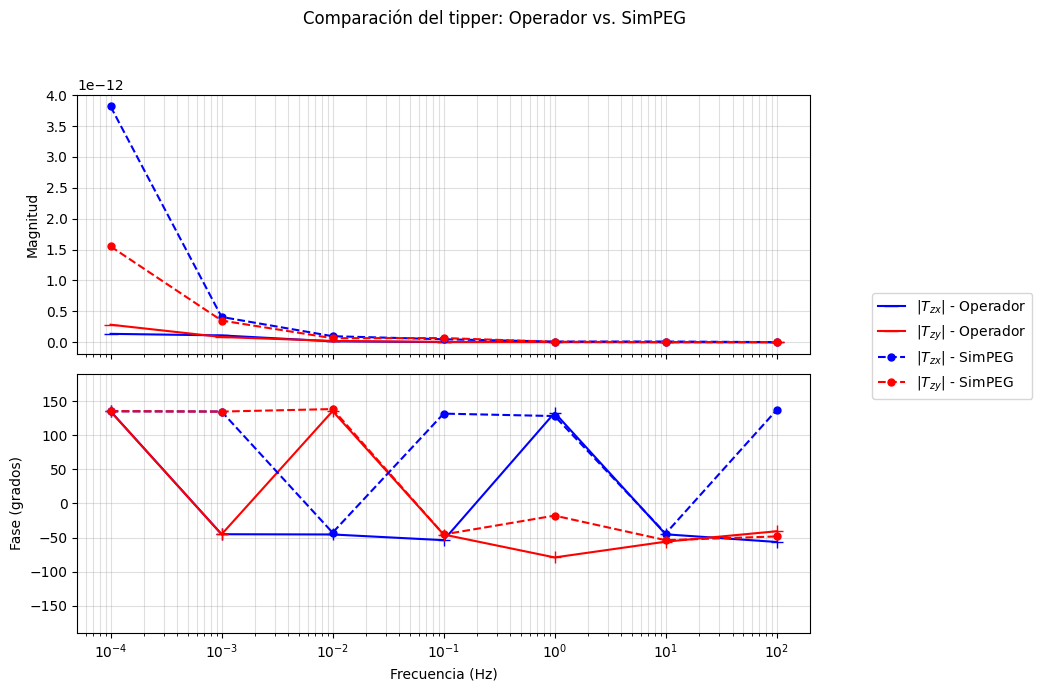

In [16]:
# Tipper: Magnitud y fase

# Extraer receptor y componentes Tzx / Tzy
irec = 0

orden = np.argsort(frequency_list)
frec = frequency_list[orden]

# Operador 
Tzx_op = tipper_op[irec, orden, 0]
Tzy_op = tipper_op[irec, orden, 1]

# SimPEG
Tzx_sp = tipper_sp[irec, orden, 0]
Tzy_sp = tipper_sp[irec, orden, 1]

# Magnitud
mag_tzx_op = np.abs(Tzx_op)
mag_tzy_op = np.abs(Tzy_op)

mag_tzx_sp = np.abs(Tzx_sp)
mag_tzy_sp = np.abs(Tzy_sp)

# Fase
phi_tzx_op = np.degrees(np.angle(Tzx_op))
phi_tzy_op = np.degrees(np.angle(Tzy_op))

phi_tzx_sp = np.degrees(np.angle(Tzx_sp))
phi_tzy_sp = np.degrees(np.angle(Tzy_sp))

# Plot comparativo del tipper

fig, (ax_mag, ax_phi) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True
)

# Magnitud
ax_mag.plot(
    frec, mag_tzx_op,
    color="blue", linestyle="-", marker="_",
    linewidth=1.5, markersize=10,
    label=r"$|T_{zx}|$ - Operador"
)

ax_mag.plot(
    frec, mag_tzy_op,
    color="red", linestyle="-", marker="_",
    linewidth=1.5, markersize=10,
    label=r"$|T_{zy}|$ - Operador"
)

ax_mag.plot(
    frec, mag_tzx_sp,
    color="blue", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label=r"$|T_{zx}|$ - SimPEG"
)

ax_mag.plot(
    frec, mag_tzy_sp,
    color="red", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label=r"$|T_{zy}|$ - SimPEG"
)

ax_mag.set_xscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="both", alpha=0.4)

# Fase
ax_phi.plot(
    frec, phi_tzx_op,
    color="blue", linestyle="-", marker="+",
    linewidth=1.5, markersize=8,
    label=r"Fase $T_{zx}$ - Operador"
)

ax_phi.plot(
    frec, phi_tzy_op,
    color="red", linestyle="-", marker="+",
    linewidth=1.5, markersize=8,
    label=r"Fase $T_{zy}$ - Operador"
)

ax_phi.plot(
    frec, phi_tzx_sp,
    color="blue", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label=r"Fase $T_{zx}$ - SimPEG"
)

ax_phi.plot(
    frec, phi_tzy_sp,
    color="red", linestyle="--", marker="o",
    linewidth=1.5, markersize=5,
    label=r"Fase $T_{zy}$ - SimPEG"
)

ax_phi.set_xscale("log")
ax_phi.set_xlabel("Frecuencia (Hz)")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_ylim(-190, 190)
ax_phi.grid(True, which="both", alpha=0.4)

ax_mag.invert_xaxis()
ax_phi.invert_xaxis()

handles, labels = ax_mag.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.87, 0.5)
)

fig.suptitle("Comparación del tipper: Operador vs. SimPEG")

plt.tight_layout(rect=[0, 0, 0.83, 0.95])
plt.savefig("Tipper_Operador-SimPEG.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
import numpy as np

def metricas_error(operador, simpeg, nombre="Variable"):
    operador = np.asarray(operador, dtype=float)
    simpeg = np.asarray(simpeg, dtype=float)

    # Eliminar NaN, inf y evitar divisiones por cero en MAPE
    mask = (
        np.isfinite(operador)
        & np.isfinite(simpeg)
        & (np.abs(simpeg) > 1e-12)
    )

    operador = operador[mask]
    simpeg = simpeg[mask]

    error = operador - simpeg

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    mape = np.mean(np.abs(error / simpeg)) * 100

    print(f"\n{nombre}")
    print(f"MAE  = {mae:.4f} Ω·m")
    print(f"RMSE = {rmse:.4f} Ω·m")
    print(f"MAPE = {mape:.2f} %")

    return mae, rmse, mape


print("=" * 55)
print("ERROR DEL OPERADOR RESPECTO A SIMPEG")
print("=" * 55)

metricas_error(
    rho_xy_op,
    rho_xy_sp,
    nombre="Resistividad aparente XY"
)

metricas_error(
    rho_yx_op,
    rho_yx_sp,
    nombre="Resistividad aparente YX" 
    
)

ERROR DEL OPERADOR RESPECTO A SIMPEG

Resistividad aparente XY
MAE  = 4.8178 Ω·m
RMSE = 5.2967 Ω·m
MAPE = 40.67 %

Resistividad aparente YX
MAE  = 4.8178 Ω·m
RMSE = 5.2967 Ω·m
MAPE = 40.67 %


(np.float64(4.817836696243431),
 np.float64(5.296719283626556),
 np.float64(40.66898946462056))